# Multivariate Change Point Detection Regime Segmentation
Here we implement a multivariate change point detection approach. Unlike HMMs which assume hidden states that we transition between, change point detection looks for structural breaks in the statistical properties of the time series.

In [127]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')
import matplotlib.dates as mdates

data_path = r'../../../data/master_data.csv'
df = pd.read_csv(data_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (8107, 26)


,Date,GSPC,VIX,SPY Volume,Oil,GDP,Core_Inflation,Unemployment,M2,Sentiment,...,MACD_Signal,MACD_Hist,GDP_YoY,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime
0,1994-01-27,477.049988,10.30,344500.0,15.48,10939.116,66.902,6.6,3474.9,94.3,...,1.997186,-0.061014,0.034307,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,NaN
1,1994-01-28,478.700012,9.94,356500.0,15.37,10939.116,66.902,6.6,3474.9,94.3,...,2.041544,0.177433,0.034307,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,NaN
2,1994-01-31,481.609985,10.63,313800.0,15.24,10939.116,66.902,6.6,3474.9,94.3,...,2.162714,0.484681,0.034307,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,NaN
3,1994-02-01,479.619995,10.65,303600.0,15.91,10939.116,67.047,6.6,3475.7,93.2,...,2.288998,0.505137,0.034307,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,NaN
4,1994-02-02,482.000000,10.61,307600.0,16.06,10939.116,67.047,6.6,3475.7,93.2,...,2.444622,0.622496,0.034307,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,NaN


## Fetch Consumer Sentiment from FRED API
Mirrors the GMM notebook's feature engineering: fetch the University of Michigan Consumer Sentiment Index (UMCSENT), then derive month-over-month change and a rolling 12-month z-score.

In [128]:
load_dotenv()
fred = Fred(api_key=os.getenv('FRED_API_KEY', 'edf185d621148e61f50e97f856494963'))

sentiment = fred.get_series('UMCSENT').to_frame('Consumer_Sentiment')
sentiment.index = pd.to_datetime(sentiment.index)
sentiment = sentiment.resample('D').ffill()

df = df.merge(sentiment, left_on='Date', right_index=True, how='left')
df['Consumer_Sentiment'] = df['Consumer_Sentiment'].ffill().bfill()

# Month-over-month change (21 trading days ≈ 1 calendar month)
df['Consumer_Sentiment_MoM'] = df['Consumer_Sentiment'].diff(21)

# Rolling 12-month z-score (252 trading days, min_periods=63)
rolling_mean = df['Consumer_Sentiment'].rolling(252, min_periods=63).mean()
rolling_std  = df['Consumer_Sentiment'].rolling(252, min_periods=63).std()
df['Consumer_Sentiment_ZScore'] = (df['Consumer_Sentiment'] - rolling_mean) / rolling_std

print(f"Consumer Sentiment features added. Shape: {df.shape}")
print(f"Consumer_Sentiment NaN: {df['Consumer_Sentiment'].isna().sum()}")
print(f"Consumer_Sentiment_ZScore NaN: {df['Consumer_Sentiment_ZScore'].isna().sum()}")

Consumer Sentiment features added. Shape: (8107, 29)
Consumer_Sentiment NaN: 0
Consumer_Sentiment_ZScore NaN: 62


In [129]:
candidate_features = [
    'Return',
    'VIX', 'Drawdown',
    'RSI_14', 'MACD_Hist',
    'Consumer_Sentiment_ZScore',
    'Oil'
]

print(f"Candidate features ({len(candidate_features)}): {candidate_features}")

# Build working dataframe
df_work = df[['Date', price_col, ret_col] + [c for c in candidate_features if c not in [ret_col]]].copy()

print("\nMissing values BEFORE cleaning:")
print(df_work[candidate_features].isnull().sum())

df_work[candidate_features] = df_work[candidate_features].ffill(limit=5)
df_work[candidate_features] = df_work[candidate_features].interpolate(method='linear')

rows_before = len(df_work)
df_work = df_work.dropna(subset=candidate_features).reset_index(drop=True)
rows_after = len(df_work)

print(f"\nMissing values AFTER cleaning:")
print(df_work[candidate_features].isnull().sum())
print(f"\nRows dropped: {rows_before - rows_after} (from {rows_before} to {rows_after})")

Candidate features (7): ['Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Oil']

Missing values BEFORE cleaning:
Return                        0
VIX                           0
Drawdown                      0
RSI_14                        0
MACD_Hist                     0
Consumer_Sentiment_ZScore    62
Oil                           0
dtype: int64

Missing values AFTER cleaning:
Return                       0
VIX                          0
Drawdown                     0
RSI_14                       0
MACD_Hist                    0
Consumer_Sentiment_ZScore    0
Oil                          0
dtype: int64

Rows dropped: 62 (from 8107 to 8045)


## Collinearity Analysis
Check for highly correlated features and remove redundant ones (threshold: |r| > 0.8), matching the GMM notebook's feature selection approach.

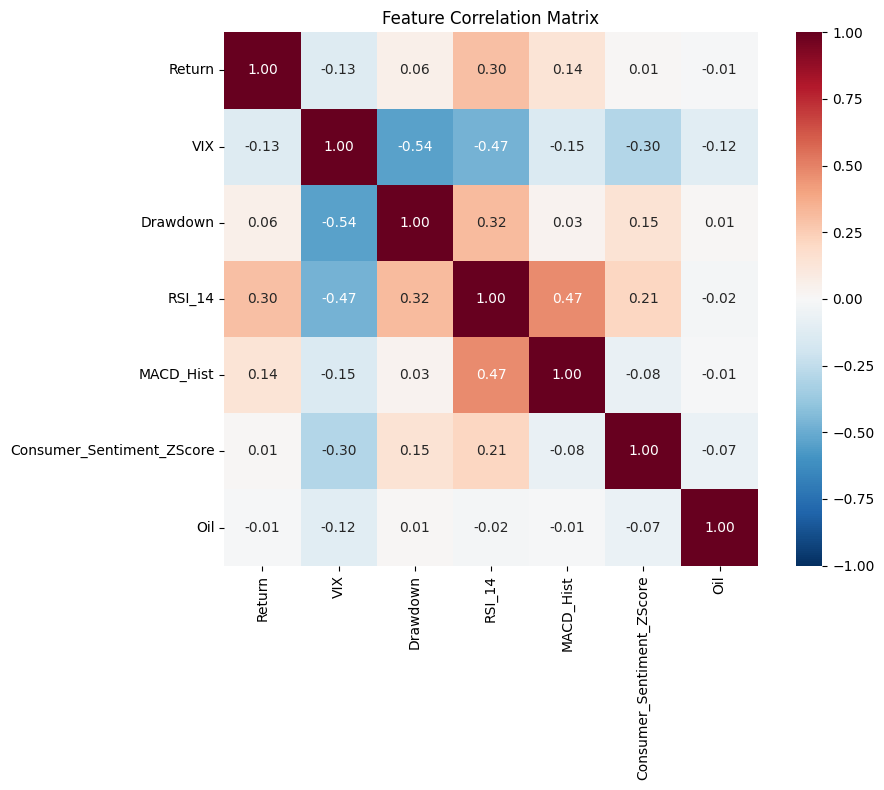

In [130]:
corr_matrix = df_work[candidate_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [131]:
collinearity_threshold = 0.8

upper_tri = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and abs(val) > collinearity_threshold:
            high_corr_pairs.append((idx, col, round(val, 3)))

if high_corr_pairs:
    print(f"Highly correlated pairs (|r| > {collinearity_threshold}):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} <-> {f2}: r = {r}")
else:
    print("No highly correlated pairs found.")

features_to_drop = set()
for f1, f2, r in high_corr_pairs:
    if f1 not in features_to_drop and f2 not in features_to_drop:
        count_f1 = sum(1 for a, b, _ in high_corr_pairs if a == f1 or b == f1)
        count_f2 = sum(1 for a, b, _ in high_corr_pairs if a == f2 or b == f2)
        drop = f1 if count_f1 >= count_f2 else f2
        features_to_drop.add(drop)

selected_features = [f for f in candidate_features if f not in features_to_drop]

print(f"\nFeatures removed due to collinearity: {sorted(features_to_drop)}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

No highly correlated pairs found.

Features removed due to collinearity: []
Selected features (7): ['Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Oil']


## Standardise Selected Features

In [132]:
scaler = StandardScaler()
X_raw = df_work[selected_features].values
X = scaler.fit_transform(X_raw)

print(f"Feature matrix shape: {X.shape}")
print(f"Post-standardisation means:  {X.mean(axis=0).round(6)}")
print(f"Post-standardisation stds:   {X.std(axis=0).round(6)}")

Feature matrix shape: (8045, 7)
Post-standardisation means:  [ 0.  0. -0. -0.  0.  0.  0.]
Post-standardisation stds:   [1. 1. 1. 1. 1. 1. 1.]


Apply Ruptures (PELT) for CPD

In [133]:
print("Running Pelt search algorithm with BIC-based penalty selection...")

n = len(X)
k = X.shape[1]

algo = rpt.Pelt(model="rbf", min_size=20).fit(X)

# Select penalty by minimising BIC across a grid
best_pen = 5  # fallback
best_bic = np.inf
for pen in [1, 3, 5, 10, 15, 25]:
    bkps = algo.predict(pen=pen)
    n_segments = len(bkps)
    cost = algo.cost.sum_of_costs(bkps)
    bic = cost + n_segments * k * np.log(n)
    if bic < best_bic:
        best_bic = bic
        best_pen = pen

result = algo.predict(pen=best_pen)

print(f"Selected penalty: {best_pen} (BIC: {best_bic:.2f})")
print(f"Found {len(result) - 1} change points.")
print(f"Change point indices: {result[:-1]}")

Running Pelt search algorithm with BIC-based penalty selection...
Selected penalty: 25 (BIC: 4527.26)
Found 19 change points.
Change point indices: [550, 1010, 1625, 1915, 2060, 2255, 2610, 3110, 3335, 3630, 3780, 4075, 4465, 5185, 6500, 6690, 6980, 7220, 7555]


Map segments to Regimes (Bull/Bear)

In [134]:
df_work['regime'] = 'unknown'
df_work['segment'] = 0

start_idx = 0
for i, end_idx in enumerate(result):
    segment_data = df_work.iloc[start_idx:end_idx]
    
    # mean return for the segment
    mean_ret = segment_data[ret_col].mean()
    
    # simple heuristic: positive mean return -> bull, negative -> bear
    regime = 'bull' if mean_ret > 0 else 'bear'
    
    df_work.loc[start_idx:end_idx-1, 'regime'] = regime
    df_work.loc[start_idx:end_idx-1, 'segment'] = i
    
    start_idx = end_idx

if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

df = df.merge(df_work[['Date', 'regime', 'segment']], on='Date', how='left')
first_regime = df_work['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))


Regime Counts:
regime
bull    6792
bear    1315
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.838
bear    0.162
Name: proportion, dtype: float64


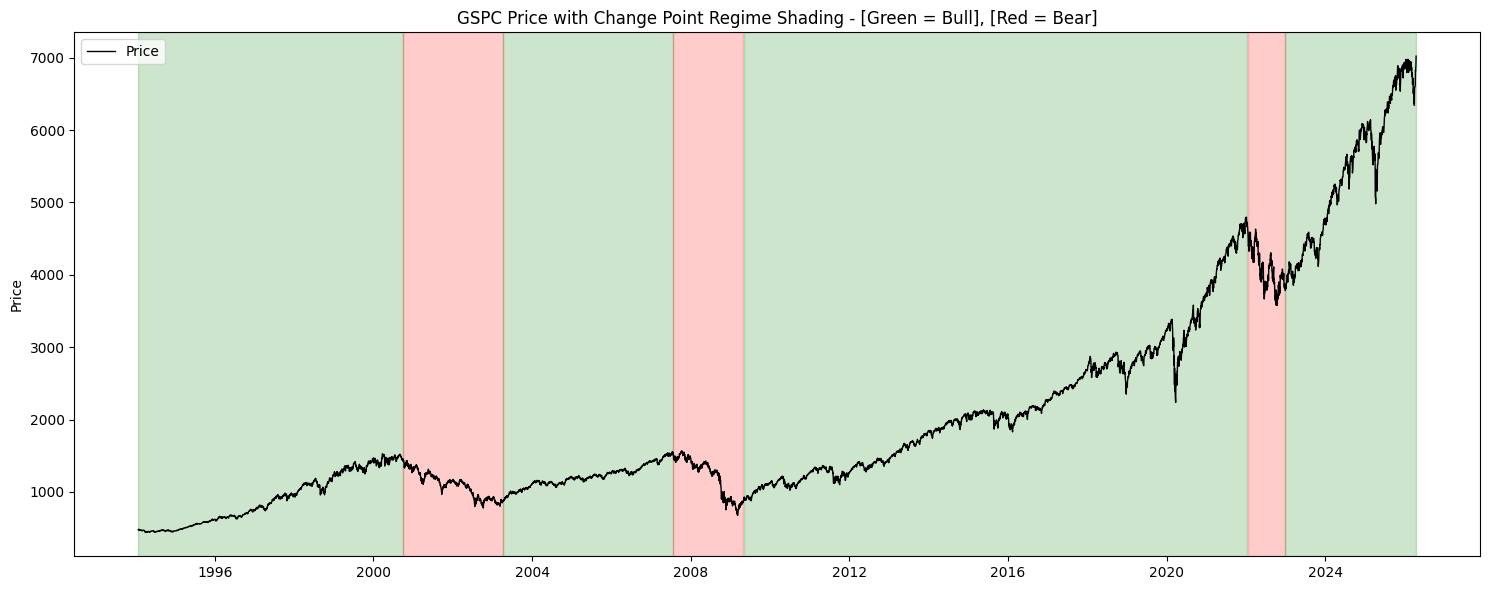

In [135]:
fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))
ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.set_title(f'{price_col} Price with Change Point Regime Shading - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Add shading
df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [136]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

output_csv = r'../../../data/multivariate_changepoint_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")

Validation passed: No missing values in 'regime' column.
Dataset saved to ../../../data/multivariate_changepoint_labeled_dataset.csv


In [137]:
# =============================================================================
# PILLAR 2: REAL DATA VALIDATION
# =============================================================================

from scipy import stats
df_work = df.copy()

# --- 1. NBER Recession Dates (official US recession periods) ---
nber_periods = [
    ('1994-01-27', '2001-02-28', 'bull', '1990s Expansion'),
    ('2001-03-01', '2001-11-30', 'bear', '2001 Recession (Dot-Com)'),
    ('2001-12-01', '2007-11-30', 'bull', 'Early 2000s Expansion'),
    ('2007-12-01', '2009-06-30', 'bear', 'Great Recession (GFC)'),
    ('2009-07-01', '2020-01-31', 'bull', 'Post-GFC Expansion'),
    ('2020-02-01', '2020-04-30', 'bear', 'COVID-19 Recession'),
    ('2020-05-01', '2025-12-31', 'bull', 'Post-COVID Recovery'),
]

# Create NBER ground truth column
df_work['nber_regime'] = 'bull'  # default
for start, end, regime, _ in nber_periods:
    mask = (df_work['Date'] >= start) & (df_work['Date'] <= end)
    df_work.loc[mask, 'nber_regime'] = regime

print("NBER Business Cycle Ground Truth")
print("=" * 75)
print(f"{'Period':<35s} {'Expected':<8s} {'Days':>5s} {'Match%':>8s}")
print("-" * 75)

for start, end, expected, name in nber_periods:
    mask = (df_work['Date'] >= start) & (df_work['Date'] <= end)
    if mask.sum() == 0:
        print(f"  {name:<35s}  {'—':>30s} No data in range")
        continue
    period_data = df_work.loc[mask]
    match_pct = (period_data['regime'] == expected).mean() * 100
    n_days = mask.sum()
    print(f"  {name:<35s} {expected:<8s} {n_days:>5d} {match_pct:>7.1f}%")

# Aggregated stats
print(f"\n{'Aggregated':}")
nber_acc = (df_work['regime'] == df_work['nber_regime']).mean()
nber_bear_mask = df_work['nber_regime'] == 'bear'
nber_bear_recall = (df_work.loc[nber_bear_mask, 'regime'] == 'bear').mean() if nber_bear_mask.sum() > 0 else 0
pred_bear_mask = df_work['regime'] == 'bear'
nber_bear_precision = (df_work.loc[pred_bear_mask, 'nber_regime'] == 'bear').mean() if pred_bear_mask.sum() > 0 else 0

from sklearn.metrics import classification_report, confusion_matrix

# --- NBER Aggregated ---
print(f"\nAggregated (vs NBER):")
print(classification_report(df_work['nber_regime'], df_work['regime'],
                            target_names=['bear', 'bull']))
cm = confusion_matrix(df_work['nber_regime'], df_work['regime'], labels=['bear', 'bull'])
print(pd.DataFrame(cm, index=['True Bear', 'True Bull'], columns=['Pred Bear', 'Pred Bull']))


# --- 2. 20% Drawdown Rule ---
peak = df_work[price_col].cummax()
drawdown_from_peak = (df_work[price_col] - peak) / peak

in_bear = False
df_work['drawdown_regime'] = 'bull'
for i in range(len(df_work)):
    if drawdown_from_peak.iloc[i] <= -0.20:
        in_bear = True
    elif in_bear and drawdown_from_peak.iloc[i] >= -0.05:
        in_bear = False
    if in_bear:
        df_work.loc[df_work.index[i], 'drawdown_regime'] = 'bear'

# Identify contiguous drawdown bear periods and label them
dd_changes = (df_work['drawdown_regime'] != df_work['drawdown_regime'].shift(1)).cumsum()
dd_bear_num = 0

print("\n\n20% Drawdown Rule Ground Truth")
print("=" * 75)
print(f"{'Period':<40s} {'Expected':<8s} {'Days':>5s} {'Match%':>8s}")
print("-" * 75)

for _, group in df_work.groupby(dd_changes):
    r = group['drawdown_regime'].iloc[0]
    s = group['Date'].iloc[0].strftime('%Y-%m-%d')
    e = group['Date'].iloc[-1].strftime('%Y-%m-%d')
    n = len(group)
    match_pct = (group['regime'] == r).mean() * 100

    if r == 'bear':
        dd_bear_num += 1
        label = f"Bear {dd_bear_num} ({s} to {e})"
    else:
        label = f"Bull ({s} to {e})"

    # Only print bear periods and bulls longer than 250 days to keep output readable
    if r == 'bear' or n > 250:
        print(f"  {label:<40s} {r:<8s} {n:>5d} {match_pct:>7.1f}%")

# Aggregated stats
print(f"\n{'Aggregated':}")
dd_acc = (df_work['regime'] == df_work['drawdown_regime']).mean()
dd_bear_mask = df_work['drawdown_regime'] == 'bear'
dd_bear_recall = (df_work.loc[dd_bear_mask, 'regime'] == 'bear').mean() if dd_bear_mask.sum() > 0 else 0
dd_pred_bear_mask = df_work['regime'] == 'bear'
dd_bear_precision = (df_work.loc[dd_pred_bear_mask, 'drawdown_regime'] == 'bear').mean() if dd_pred_bear_mask.sum() > 0 else 0

# --- Drawdown Aggregated ---
print(f"\nAggregated (vs 20% Drawdown Rule):")
print(classification_report(df_work['drawdown_regime'], df_work['regime'],
                            target_names=['bear', 'bull']))
cm = confusion_matrix(df_work['drawdown_regime'], df_work['regime'], labels=['bear', 'bull'])
print(pd.DataFrame(cm, index=['True Bear', 'True Bull'], columns=['Pred Bear', 'Pred Bull']))

NBER Business Cycle Ground Truth
Period                              Expected  Days   Match%
---------------------------------------------------------------------------
  1990s Expansion                     bull      1789    94.3%
  2001 Recession (Dot-Com)            bear       188   100.0%
  Early 2000s Expansion               bull      1510    71.5%
  Great Recession (GFC)               bear       397    89.4%
  Post-GFC Expansion                  bull      2665   100.0%
  COVID-19 Recession                  bear        62     0.0%
  Post-COVID Recovery                 bull      1425    83.2%

Aggregated

Aggregated (vs NBER):
              precision    recall  f1-score   support

        bear       0.41      0.84      0.55       647
        bull       0.98      0.90      0.94      7460

    accuracy                           0.89      8107
   macro avg       0.70      0.87      0.75      8107
weighted avg       0.94      0.89      0.91      8107

           Pred Bear  Pred Bull
Tru

In [ ]:
# =============================================================================
# STATISTICAL SIGNIFICANCE OF REGIME SEPARATION
# =============================================================================

print("Statistical Significance of PELT Regime Labels")
print("=" * 70)
print("H0: No difference between bull and bear regime distributions")
print("Test: Welch's t-test (unequal variances)\n")

bull_mask = df_work['regime'] == 'bull'
bear_mask = df_work['regime'] == 'bear'

test_features = {
    'Daily Return':     ret_col,
    'VIX':              'VIX',
    'Drawdown':         'Drawdown',
    'RSI_14':           'RSI_14',
    'MACD_Hist':        'MACD_Hist',
}

results = []
for name, col in test_features.items():
    bull_vals = df_work.loc[bull_mask, col].dropna()
    bear_vals = df_work.loc[bear_mask, col].dropna()

    t_stat, p_val = stats.ttest_ind(bull_vals, bear_vals, equal_var=False)

    results.append({
        'Feature': name,
        'Bull Mean': bull_vals.mean(),
        'Bear Mean': bear_vals.mean(),
        'Difference': bull_vals.mean() - bear_vals.mean(),
        't-statistic': t_stat,
        'p-value': p_val,
        'Significant (p<0.01)': 'Yes' if p_val < 0.01 else 'No',
    })

    print(f"  {name:15s} | Bull: {bull_vals.mean():+.6f} | Bear: {bear_vals.mean():+.6f} | "
          f"t={t_stat:+.2f} | p={p_val:.2e} | {'***' if p_val < 0.01 else 'n.s.'}")

# Also test volatility (std of returns in rolling windows)
bull_vol = df_work.loc[bull_mask, ret_col].rolling(21).std().dropna()
bear_vol = df_work.loc[bear_mask, ret_col].rolling(21).std().dropna()
t_stat, p_val = stats.ttest_ind(bull_vol, bear_vol, equal_var=False)
print(f"  {'21d Volatility':15s} | Bull: {bull_vol.mean():+.6f} | Bear: {bear_vol.mean():+.6f} | "
      f"t={t_stat:+.2f} | p={p_val:.2e} | {'***' if p_val < 0.01 else 'n.s.'}")

# Kolmogorov-Smirnov test on return distributions
ks_stat, ks_p = stats.ks_2samp(
    df_work.loc[bull_mask, ret_col].dropna(),
    df_work.loc[bear_mask, ret_col].dropna()
)
print(f"\n  Kolmogorov-Smirnov test on return distributions:")
print(f"    KS statistic: {ks_stat:.4f} | p-value: {ks_p:.2e}")
print(f"    {'Distributions are significantly different' if ks_p < 0.01 else 'Cannot reject identical distributions'}")

Statistical Significance of PELT Regime Labels
H0: No difference between bull and bear regime distributions
Test: Welch's t-test (unequal variances)

  Daily Return    | Bull: +0.000634 | Bear: -0.000798 | t=+2.78 | p=5.58e-03 | ***
  VIX             | Bull: +18.050375 | Bear: +28.473407 | t=-37.49 | p=3.37e-219 | ***
  Drawdown        | Bull: -0.085713 | Bear: -0.239091 | t=+38.58 | p=1.86e-231 | ***
  RSI_14          | Bull: +56.068121 | Bear: +46.465218 | t=+31.52 | p=2.66e-177 | ***
  MACD_Hist       | Bull: -0.004652 | Bear: -0.008405 | t=+0.01 | p=9.90e-01 | n.s.
  21d Volatility  | Bull: +0.008754 | Bear: +0.016535 | t=-33.47 | p=1.36e-183 | ***

  Kolmogorov-Smirnov test on return distributions:
    KS statistic: 0.1789 | p-value: 2.70e-31
    Distributions are significantly different


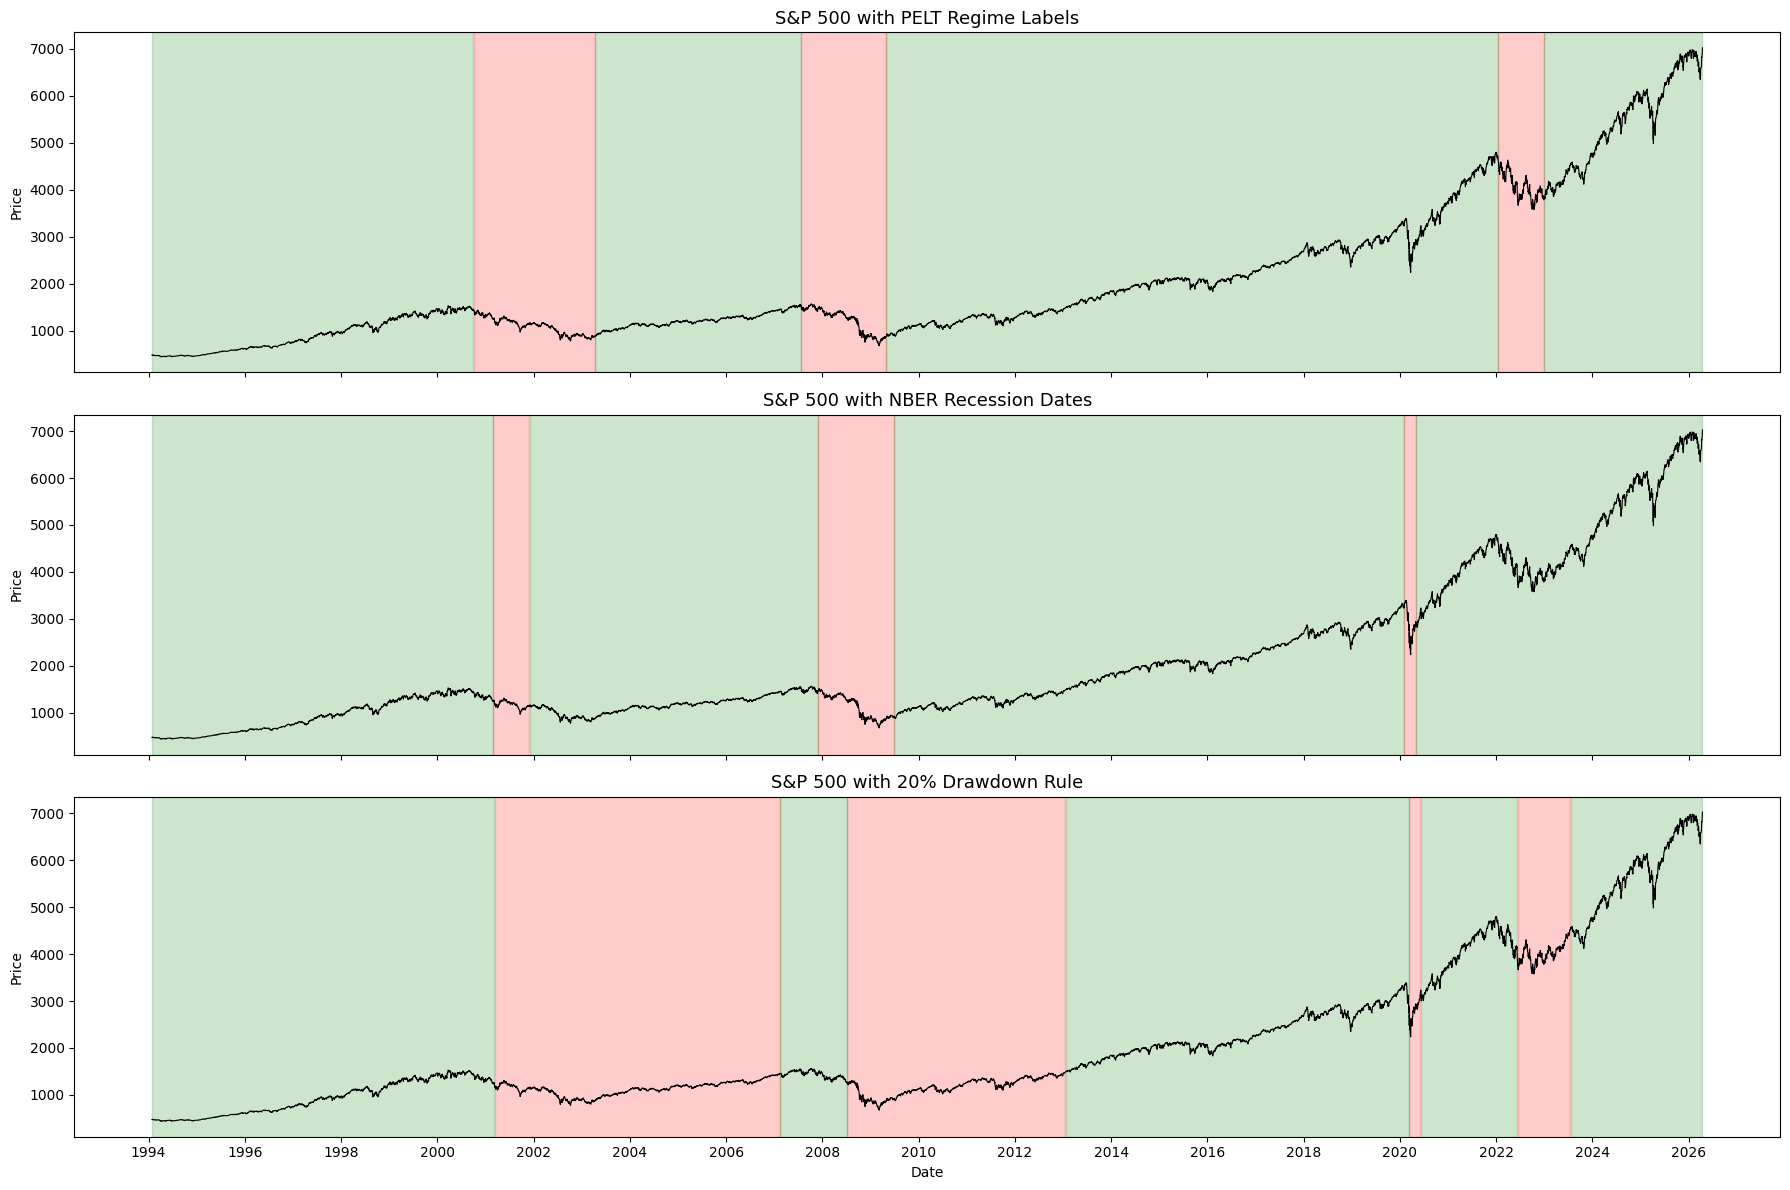

In [139]:
# =============================================================================
# VISUAL COMPARISON: PELT vs NBER vs 20% DRAWDOWN
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

for ax, (label, regime_col) in zip(axes, [
    ('PELT Regime Labels', 'regime'),
    ('NBER Recession Dates', 'nber_regime'),
    ('20% Drawdown Rule', 'drawdown_regime'),
]):
    ax.plot(df_work['Date'], df_work[price_col], color='black', linewidth=0.8)
    ax.set_title(f'S&P 500 with {label}', fontsize=13)
    ax.set_ylabel('Price')

    changes = (df_work[regime_col] != df_work[regime_col].shift(1)).cumsum()
    for _, group in df_work.groupby(changes):
        s = group['Date'].iloc[0]
        e = group['Date'].iloc[-1]
        r = group[regime_col].iloc[0]
        ax.axvspan(s, e, color='green' if r == 'bull' else 'red', alpha=0.2)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [141]:
# =============================================================================
# STATISTICAL SIGNIFICANCE: PAIRWISE MODEL COMPARISON (McNemar's Test)
# =============================================================================
from statsmodels.stats.contingency_tables import mcnemar

# Load the other model predictions
gmm_df = pd.read_csv('../../../data/multivariate_gmm_labeled_dataset.csv')
hmm_df = pd.read_csv('../../../data/multivariate_hmm_labeled_dataset.csv')

gmm_df['Date'] = pd.to_datetime(gmm_df['Date'])
hmm_df['Date'] = pd.to_datetime(hmm_df['Date'])

# Merge predictions onto df_work (which already has PELT regime + ground truths)
df_work = df_work.merge(gmm_df[['Date', 'regime']].rename(columns={'regime': 'regime_gmm'}), on='Date')
df_work = df_work.merge(hmm_df[['Date', 'regime']].rename(columns={'regime': 'regime_hmm'}), on='Date')

def mcnemar_test(y_true, pred_a, pred_b, name_a, name_b):
    """Run McNemar's test comparing two models on the same ground truth."""
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    
    n11 = np.sum( correct_a &  correct_b)
    n10 = np.sum( correct_a & ~correct_b)  # A right, B wrong
    n01 = np.sum(~correct_a &  correct_b)  # A wrong, B right
    n00 = np.sum(~correct_a & ~correct_b)
    
    table = np.array([[n11, n10],
                      [n01, n00]])
    
    result = mcnemar(table, exact=False, correction=True)
    return {
        'Comparison': f"{name_a} vs {name_b}",
        f'{name_a} right, {name_b} wrong': n10,
        f'{name_a} wrong, {name_b} right': n01,
        'Chi-squared': result.statistic,
        'p-value': result.pvalue,
    }

model_pairs = [
    ('regime', 'regime_gmm', 'PELT', 'GMM'),
    ('regime', 'regime_hmm', 'PELT', 'HMM'),
    ('regime_gmm', 'regime_hmm', 'GMM', 'HMM'),
]

for gt_name, gt_col in [('NBER', 'nber_regime'), ('20% Drawdown', 'drawdown_regime')]:
    print(f"\n{'='*70}")
    print(f"McNemar's Test — Pairwise Model Comparison (vs {gt_name})")
    print(f"{'='*70}")
    print(f"H0: Both models have the same error rate")
    print(f"Bonferroni correction applied for 3 comparisons\n")
    
    y_true = df_work[gt_col]
    
    results = []
    for col_a, col_b, name_a, name_b in model_pairs:
        res = mcnemar_test(y_true, df_work[col_a], df_work[col_b], name_a, name_b)
        results.append(res)
    
    for res in results:
        adj_p = min(res['p-value'] * 3, 1.0)  # Bonferroni
        sig = '***' if adj_p < 0.01 else '**' if adj_p < 0.05 else 'n.s.'
        print(f"  {res['Comparison']:15s} | "
              f"Disagreements: {list(res.values())[1]:>4d} vs {list(res.values())[2]:>4d} | "
              f"χ²={res['Chi-squared']:.2f} | "
              f"p={res['p-value']:.2e} | adj-p={adj_p:.2e} | {sig}")


McNemar's Test — Pairwise Model Comparison (vs NBER)
H0: Both models have the same error rate
Bonferroni correction applied for 3 comparisons

  PELT vs GMM     | Disagreements: 1124 vs  320 | χ²=446.54 | p=4.08e-99 | adj-p=1.22e-98 | ***
  PELT vs HMM     | Disagreements: 1461 vs  248 | χ²=859.53 | p=6.15e-189 | adj-p=1.84e-188 | ***
  GMM vs HMM      | Disagreements:  491 vs   82 | χ²=290.51 | p=3.84e-65 | adj-p=1.15e-64 | ***

McNemar's Test — Pairwise Model Comparison (vs 20% Drawdown)
H0: Both models have the same error rate
Bonferroni correction applied for 3 comparisons

  PELT vs GMM     | Disagreements: 1033 vs  411 | χ²=267.06 | p=4.95e-60 | adj-p=1.49e-59 | ***
  PELT vs HMM     | Disagreements: 1096 vs  613 | χ²=135.94 | p=2.05e-31 | adj-p=6.16e-31 | ***
  GMM vs HMM      | Disagreements:  217 vs  356 | χ²=33.24 | p=8.16e-09 | adj-p=2.45e-08 | ***


In [148]:
import numpy as np


def bootstrap_metric_comparison_fast(
    y_true, pred_a, pred_b,
    name_a='PELT', name_b='GMM',
    n_bootstrap=10000,
    block_size=63,
    alpha=0.05,
    seed=None,
):
    """
    Block bootstrap comparison of two binary classifiers (labels in
    {'bull', 'bear'}) on accuracy and per-class precision/recall/F1,
    plus macro-averaged precision/recall/F1.

    Returns a dict keyed by metric name, each entry containing observed
    values for A and B, their difference, 95% CI on the difference, and
    one-sided p-value for the hypothesis that A outperforms B.
    """
    rng = np.random.default_rng(seed)

    if hasattr(y_true, 'values'): y_true = y_true.values
    if hasattr(pred_a, 'values'): pred_a = pred_a.values
    if hasattr(pred_b, 'values'): pred_b = pred_b.values

    n = len(y_true)

    # Encode once: bear = True, bull = False
    yt = (y_true == 'bear')
    pa = (pred_a == 'bear')
    pb = (pred_b == 'bear')

    # Per-sample contributions for each class. For bull, TP/FP/FN are just
    # the negated versions of the bear counterparts (bull TP = both ~bear,
    # bull FP = predicted ~bear but actually bear, etc).
    def contribs(pred):
        correct   = (pred == yt)
        tp_bear   = pred & yt
        fp_bear   = pred & ~yt
        fn_bear   = ~pred & yt
        tp_bull   = ~pred & ~yt
        fp_bull   = ~pred & yt       # predicted bull, actually bear
        fn_bull   = pred & ~yt       # predicted bear, actually bull
        return correct, tp_bear, fp_bear, fn_bear, tp_bull, fp_bull, fn_bull

    a_c, a_tpB, a_fpB, a_fnB, a_tpb, a_fpb, a_fnb = contribs(pa)
    b_c, b_tpB, b_fpB, b_fnB, b_tpb, b_fpb, b_fnb = contribs(pb)

    def safe_div(num, den):
        return np.divide(num, den, out=np.zeros_like(num, dtype=float), where=den > 0)

    def metrics_from_sums(c, tpB, fpB, fnB, tpb, fpb, fnb, total):
        acc        = c / total
        prec_bear  = safe_div(tpB, tpB + fpB)
        rec_bear   = safe_div(tpB, tpB + fnB)
        f1_bear    = safe_div(2 * prec_bear * rec_bear, prec_bear + rec_bear)
        prec_bull  = safe_div(tpb, tpb + fpb)
        rec_bull   = safe_div(tpb, tpb + fnb)
        f1_bull    = safe_div(2 * prec_bull * rec_bull, prec_bull + rec_bull)
        prec_macro = (prec_bear + prec_bull) / 2
        rec_macro  = (rec_bear + rec_bull) / 2
        f1_macro   = (f1_bear + f1_bull) / 2
        return {
            'Accuracy':       acc,
            'Bear Precision': prec_bear,
            'Bear Recall':    rec_bear,
            'Bear F1':        f1_bear,
            'Bull Precision': prec_bull,
            'Bull Recall':    rec_bull,
            'Bull F1':        f1_bull,
            'Macro Precision': prec_macro,
            'Macro Recall':    rec_macro,
            'Macro F1':        f1_macro,
        }

    # Observed values on full sample (scalars, reuse the same function via arrays of size 1)
    obs_a = metrics_from_sums(
        np.array([a_c.sum()]), np.array([a_tpB.sum()]), np.array([a_fpB.sum()]), np.array([a_fnB.sum()]),
        np.array([a_tpb.sum()]), np.array([a_fpb.sum()]), np.array([a_fnb.sum()]), n,
    )
    obs_b = metrics_from_sums(
        np.array([b_c.sum()]), np.array([b_tpB.sum()]), np.array([b_fpB.sum()]), np.array([b_fnB.sum()]),
        np.array([b_tpb.sum()]), np.array([b_fpb.sum()]), np.array([b_fnb.sum()]), n,
    )

    # ---------- Vectorised block bootstrap ----------
    n_blocks = n // block_size + 1
    block_starts = rng.integers(0, n - block_size, size=(n_bootstrap, n_blocks))
    offsets = np.arange(block_size)
    indices = (block_starts[:, :, None] + offsets[None, None, :]).reshape(n_bootstrap, -1)[:, :n]

    def boot_sums(arr):
        return arr[indices].sum(axis=1)

    ma = metrics_from_sums(
        boot_sums(a_c), boot_sums(a_tpB), boot_sums(a_fpB), boot_sums(a_fnB),
        boot_sums(a_tpb), boot_sums(a_fpb), boot_sums(a_fnb), n,
    )
    mb = metrics_from_sums(
        boot_sums(b_c), boot_sums(b_tpB), boot_sums(b_fpB), boot_sums(b_fnB),
        boot_sums(b_tpb), boot_sums(b_fpb), boot_sums(b_fnb), n,
    )

    results = {}
    for name in ma.keys():
        diffs = ma[name] - mb[name]
        ci_low, ci_high = np.percentile(diffs, [100 * alpha / 2, 100 * (1 - alpha / 2)])
        results[name] = {
            name_a: float(obs_a[name][0]),
            name_b: float(obs_b[name][0]),
            'Difference': float(obs_a[name][0] - obs_b[name][0]),
            '95% CI': (float(ci_low), float(ci_high)),
            'p-value (A>B)': float(np.mean(diffs <= 0)),
        }
    return results

model_pairs = [
    ('regime', 'regime_gmm', 'PELT', 'GMM'),
    ('regime', 'regime_hmm', 'PELT', 'HMM'),
]

# Organise metrics into groups so the table reads cleanly
metric_groups = {
    'Overall':     ['Accuracy'],
    'Bear Class':  ['Bear Precision', 'Bear Recall', 'Bear F1'],
    'Bull Class':  ['Bull Precision', 'Bull Recall', 'Bull F1'],
    'Macro Avg':   ['Macro Precision', 'Macro Recall', 'Macro F1'],
}

for gt_name, gt_col in [('NBER', 'nber_regime'), ('20% Drawdown', 'drawdown_regime')]:
    print(f"\n{'='*84}")
    print(f"Bootstrap Metric Comparison (vs {gt_name}) — Block Size = 63 days")
    print(f"{'='*84}")

    y_true = df_work[gt_col]

    for col_a, col_b, name_a, name_b in model_pairs:
        print(f"\n  {name_a} vs {name_b}:")
        res = bootstrap_metric_comparison_fast(
            y_true, df_work[col_a], df_work[col_b],
            name_a=name_a, name_b=name_b,
            n_bootstrap=10000, seed=42,
        )

        header = f"  {'Metric':16s} | {name_a:>8s} | {name_b:>8s} | {'Diff':>8s} | {'95% CI':>20s} | {'p-value':>8s}"
        sep    = f"  {'-'*(len(header)-2)}"

        for group_name, metric_list in metric_groups.items():
            print(f"\n  [{group_name}]")
            print(header)
            print(sep)
            for metric_name in metric_list:
                r = res[metric_name]
                p = r['p-value (A>B)']
                sig = '***' if p < 0.01 else '**' if p < 0.05 else 'n.s.'
                ci = r['95% CI']
                print(f"  {metric_name:16s} | {r[name_a]:>8.4f} | {r[name_b]:>8.4f} | "
                      f"{r['Difference']:>+8.4f} | [{ci[0]:>+.4f}, {ci[1]:>+.4f}] | "
                      f"{p:>8.4f} {sig}")


Bootstrap Metric Comparison (vs NBER) — Block Size = 63 days

  PELT vs GMM:

  [Overall]
  Metric           |     PELT |      GMM |     Diff |               95% CI |  p-value
  -----------------------------------------------------------------------------------
  Accuracy         |   0.8919 |   0.7928 |  +0.0992 | [+0.0398, +0.1557] |   0.0004 ***

  [Bear Class]
  Metric           |     PELT |      GMM |     Diff |               95% CI |  p-value
  -----------------------------------------------------------------------------------
  Bear Precision   |   0.4129 |   0.2398 |  +0.1731 | [+0.0416, +0.3206] |   0.0047 ***
  Bear Recall      |   0.8393 |   0.7357 |  +0.1036 | [-0.2361, +0.4416] |   0.2807 n.s.
  Bear F1          |   0.5535 |   0.3617 |  +0.1918 | [+0.0212, +0.3578] |   0.0126 **

  [Bull Class]
  Metric           |     PELT |      GMM |     Diff |               95% CI |  p-value
  -----------------------------------------------------------------------------------
  Bull Pr

In [144]:
for start, end, expected, name in nber_periods:
    if expected != 'bear':
        continue
    mask = (df_work['Date'] >= start) & (df_work['Date'] <= end)
    period = df_work.loc[mask]
    
    for model_name, col in [('PELT', 'regime'), ('GMM', 'regime_gmm'), ('HMM', 'regime_hmm')]:
        bear_days = period[period[col] == 'bear']
        if len(bear_days) > 0:
            first_detect = (bear_days['Date'].iloc[0] - pd.to_datetime(start)).days
            print(f"  {name} | {model_name}: first bear detection at +{first_detect} days")
        else:
            print(f"  {name} | {model_name}: MISSED entirely")

  2001 Recession (Dot-Com) | PELT: first bear detection at +0 days
  2001 Recession (Dot-Com) | GMM: first bear detection at +0 days
  2001 Recession (Dot-Com) | HMM: first bear detection at +0 days
  Great Recession (GFC) | PELT: first bear detection at +2 days
  Great Recession (GFC) | GMM: first bear detection at +2 days
  Great Recession (GFC) | HMM: first bear detection at +2 days
  COVID-19 Recession | PELT: MISSED entirely
  COVID-19 Recession | GMM: first bear detection at +18 days
  COVID-19 Recession | HMM: first bear detection at +20 days


In [145]:
def cohens_d(group_a, group_b):
    """Compute Cohen's d (pooled std)."""
    na, nb = len(group_a), len(group_b)
    var_a, var_b = group_a.var(), group_b.var()
    pooled_std = np.sqrt(((na - 1) * var_a + (nb - 1) * var_b) / (na + nb - 2))
    return (group_a.mean() - group_b.mean()) / pooled_std

print("Regime Separation: Effect Sizes (Cohen's d)")
print("=" * 70)
print("Interpretation: |d| < 0.2 negligible, 0.2-0.5 small,")
print("                0.5-0.8 medium, > 0.8 large\n")

bull_mask = df_work['regime'] == 'bull'
bear_mask = df_work['regime'] == 'bear'

test_features = {
    'Daily Return':     ret_col,
    'VIX':              'VIX',
    'Drawdown':         'Drawdown',
    'RSI_14':           'RSI_14',
    'MACD_Hist':        'MACD_Hist',
}

for name, col in test_features.items():
    bull_vals = df_work.loc[bull_mask, col].dropna()
    bear_vals = df_work.loc[bear_mask, col].dropna()
    
    d = cohens_d(bull_vals, bear_vals)
    
    if abs(d) >= 0.8:
        magnitude = 'LARGE'
    elif abs(d) >= 0.5:
        magnitude = 'MEDIUM'
    elif abs(d) >= 0.2:
        magnitude = 'SMALL'
    else:
        magnitude = 'NEGLIGIBLE'
    
    print(f"  {name:15s} | Bull: {bull_vals.mean():+.6f} | Bear: {bear_vals.mean():+.6f} | "
          f"d={d:+.3f} | {magnitude}")

Regime Separation: Effect Sizes (Cohen's d)
Interpretation: |d| < 0.2 negligible, 0.2-0.5 small,
                0.5-0.8 medium, > 0.8 large

  Daily Return    | Bull: +0.000634 | Bear: -0.000798 | d=+0.122 | NEGLIGIBLE
  VIX             | Bull: +18.050375 | Bear: +28.473407 | d=-1.485 | LARGE
  Drawdown        | Bull: -0.085713 | Bear: -0.239091 | d=+1.400 | LARGE
  RSI_14          | Bull: +56.068121 | Bear: +46.465218 | d=+0.884 | LARGE
  MACD_Hist       | Bull: -0.004652 | Bear: -0.008405 | d=+0.000 | NEGLIGIBLE
